# Benchmark of expression level

This notebook benchmark the expression level with other methods

In [1]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## 1. SCAN-seq2 (NanoNASC-seq vs. SCAN-seq2)

In [4]:
# SCAN-seq2
d = pd.read_csv(gzip.open("../../../others/05_SCANseq2/data/GSE203561_RAW/GSM6176324_gene_counts_UMI_100.txt.gz", "rt"), sep="\t", index_col=0)
d = d[[i == i.upper() for i in d.index]] # K562 (Human genes)
d = d[d.columns[d.sum(axis=0) > 50000]]
print(d.shape)
s = d.sum(axis=1)
s.name = "SCAN-seq2"
s1 = s

(35582, 43)


In [4]:
# NanoNASC-seq
d = pd.read_csv("results/pseudobulk/expression.K562.s4U0uM180min.1TC.gene_based.annotated.tsv", sep="\t", index_col=0)
d = d[~d["GeneName"].duplicated()]
d.index = d["GeneName"]
s = d["TPM"]
s.name = "NanoNASC-seq"
s2 = s

In [5]:
m = pd.concat([s1, s2], axis=1).fillna(0)
xs = np.log2(m["SCAN-seq2"] + 1)
ys = np.log2(m["NanoNASC-seq"] + 1)
r = pearsonr(xs, ys)[0]
print(len(xs), r)
print(pearsonr(xs, ys))

39024 0.8550991708142306
PearsonRResult(statistic=0.8550991708142306, pvalue=0.0)


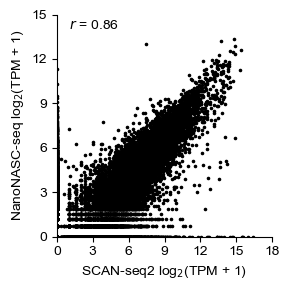

In [10]:
plt.figure(figsize=(3, 3))
plt.scatter(xs, ys, marker=".", s=10, color="black")
plt.text(1, 14, "$\it{r}$ = %.2f" % r)
plt.xlim(0, 18)
plt.ylim(0, 15)
plt.xlabel("SCAN-seq2 log$_2$(TPM + 1)")
plt.ylabel("NanoNASC-seq log$_2$(TPM + 1)")
plt.xticks(np.arange(0, 19, 3))
plt.yticks(np.arange(0, 16, 3))
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/correlation.nanonascseq_vs_scanseq2.pdf")

## 2. NASC-seq (NanoNASC-seq vs. NASC-seq)

In [7]:
# NASC-seq
d = pd.read_csv("../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U0uM180min.tsv", sep="\t")
d = d[(d["Canonical"]) & (d["GeneType"] == "protein_coding")]
d.index = d["GeneID"]
s = d["FPKM"]
s.name = "NASC-seq"
s1 = s

In [8]:
# NanoNASC-seq
d = pd.read_csv("results/pseudobulk/expression.K562.s4U0uM180min.1TC.gene_based.annotated.tsv", sep="\t", index_col=0)
s = d["TPM"]
s.name = "NanoNASC-seq"
s2 = s

In [9]:
# Merge
m = pd.concat([s1, s2], axis=1).fillna(0)
m = m[m.max(axis=1) > 0]
xs = np.log2(m["NASC-seq"] + 1)
ys = np.log2(m["NanoNASC-seq"] + 1)
r = np.corrcoef(xs, ys)[0][1]
print(len(xs), r)

19106 0.8210305967718481


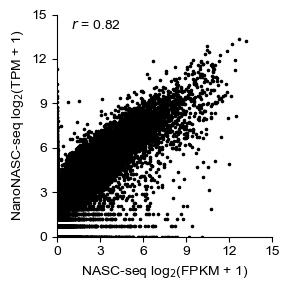

In [10]:
plt.figure(figsize=(3, 3))
plt.scatter(xs, ys, marker=".", s=10, color="black")
plt.text(1, 14, "$\it{r}$ = %.2f" % r)
plt.xlim(0, 15)
plt.ylim(0, 15)
plt.xlabel("NASC-seq log$_2$(FPKM + 1)")
plt.ylabel("NanoNASC-seq log$_2$(TPM + 1)")
plt.xticks([0, 3, 6, 9, 12, 15])
plt.yticks([0, 3, 6, 9, 12, 15])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/correlation.nanonascseq_vs_nascseq.pdf")